In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report
import kagglehub

In [ ]:
# Download latest version
path = kagglehub.dataset_download("mealss/call-transcripts-scam-determinations")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'call-transcripts-scam-determinations' dataset.
Path to dataset files: /kaggle/input/call-transcripts-scam-determinations


In [ ]:
file_path="/kaggle/input/call-transcripts-scam-determinations/BETTER30.csv"
df=pd.read_csv(file_path)

In [ ]:
df

,CONVERSATION_ID,CONVERSATION_STEP,TEXT,CONTEXT,LABEL,FEATURES,ANNOTATIONS
0,6,1,"Good morning, this is [Your Name]'s personal a...",Standard opening exchange,neutral,NaN,NaN
1,6,2,"Hello, my name is Jamie. I'm interested in vol...",Encourages the caller's interest,neutral,"welcoming, positive_tone",NaN
2,6,3,"Yes, I'm really passionate about environmental...",Reinforces anyone can volunteer,neutral,inclusive,NaN
3,6,4,"Great, how do I sign up, and where can I find ...",Demonstrates flexibility,neutral,"helpful_tone, offers_options",NaN
4,6,5,"Could you send me the link, please? And my ema...",Fulfills caller's request quickly,neutral,prompt_action,NaN
...,...,...,...,...,...,...,...
645,68,5,Would it be possible to receive some literatur...,"""Assistant requests official documentation fo...",scam_response,"""literature_request","decision_making_review"""
646,68,6,We can certainly provide information on our wo...,"""Scammer stresses the urgency of the situation.""",scam,"""immediate_action_urgency","urgency_stress"""
647,68,7,"I understand the urgency, but our policy is to...","""Assistant reiterates the policy on verifying...",scam_response,"""contribution_policy_reiteration","information_for_review_request"""
648,68,8,I'll do my best to get you the information qui...,"""Scammer promises to send information and hig...",scam,"""information_sending_promise","support_impact_highlight"""


In [ ]:
df.loc[647,"TEXT"]

'I understand the urgency, but our policy is to ensure that our contributions are going to legitimate and effective channels. Please send us the information for our review.'

In [ ]:
df["LABEL"].unique()

array(['neutral', 'slightly_suspicious', 'suspicious',
       'highly_suspicious', 'legitimate', 'scam',
       'standard_opening, identification_request', 'polite_ending',
       'potential_scam', ' neutral', ' legitimate', ' scam',
       ' scam_response', ' dismissing official protocols"',
       ' emphasizing security and compliance"',
       ' ready for further engagement"',
       ' suggesting a dangerous situation"', 'Scam',
       ' adhering to protocols"', ' citing urgency"', 'scam_response'],
      dtype=object)

In [ ]:
df['LABEL'].unique()

array(['neutral', 'slightly_suspicious', 'suspicious',
       'highly_suspicious', 'legitimate', 'scam',
       'standard_opening, identification_request', 'polite_ending',
       'potential_scam', ' neutral', ' legitimate', ' scam',
       ' scam_response', ' dismissing official protocols"',
       ' emphasizing security and compliance"',
       ' ready for further engagement"',
       ' suggesting a dangerous situation"', 'Scam',
       ' adhering to protocols"', ' citing urgency"', 'scam_response'],
      dtype=object)

In [ ]:
df['LABEL'] = df['LABEL'].map({'neutral': 'Not_Fraud', 'slightly_suspicious': 'Suspicious', 'suspicious': 'Suspicious',
       'highly_suspicious': 'Suspicious', 'legitimate':'Not_Fraud', 'scam': 'Fraud',
       'standard_opening': 'Not_Fraud', 'identification_request': 'Not_Fraud', 'polite_ending': 'Not_Fraud',
       'potential_scam':'Suspicious' , ' neutral': 'Not_Fraud', ' legitimate':'Not_Fraud', ' scam':'Fraud',
       ' scam_response': 'Fraud', ' dismissing official protocols"': 'Fraud',
       ' emphasizing security and compliance"': 'Not_Fraud',
       ' ready for further engagement"': 'Not_Fraud',
       ' suggesting a dangerous situation"':'Suspicious', 'Scam':'Fraud',
       ' adhering to protocols"': 'Not_Fraud', ' citing urgency"':'Suspicious', 'scam_response': 'Fraud'})

In [ ]:
df['LABEL'].unique()

array(['Not_Fraud', 'Suspicious', 'Fraud', nan], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CONVERSATION_ID    650 non-null    int64 
 1   CONVERSATION_STEP  650 non-null    int64 
 2   TEXT               650 non-null    object
 3   CONTEXT            647 non-null    object
 4   LABEL              649 non-null    object
 5   FEATURES           571 non-null    object
 6   ANNOTATIONS        255 non-null    object
dtypes: int64(2), object(5)
memory usage: 35.7+ KB


In [ ]:
df.isna().sum()

,0
CONVERSATION_ID,0
CONVERSATION_STEP,0
TEXT,0
CONTEXT,3
LABEL,1
FEATURES,79
ANNOTATIONS,395


In [ ]:
df.duplicated().sum()

np.int64(30)

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
CONVERSATION_ID,0
CONVERSATION_STEP,0
TEXT,0
CONTEXT,3
LABEL,1
FEATURES,75
ANNOTATIONS,365


In [ ]:
df

,CONVERSATION_ID,CONVERSATION_STEP,TEXT,CONTEXT,LABEL,FEATURES,ANNOTATIONS
0,6,1,"Good morning, this is [Your Name]'s personal a...",Standard opening exchange,Not_Fraud,NaN,NaN
1,6,2,"Hello, my name is Jamie. I'm interested in vol...",Encourages the caller's interest,Not_Fraud,"welcoming, positive_tone",NaN
2,6,3,"Yes, I'm really passionate about environmental...",Reinforces anyone can volunteer,Not_Fraud,inclusive,NaN
3,6,4,"Great, how do I sign up, and where can I find ...",Demonstrates flexibility,Not_Fraud,"helpful_tone, offers_options",NaN
4,6,5,"Could you send me the link, please? And my ema...",Fulfills caller's request quickly,Not_Fraud,prompt_action,NaN
...,...,...,...,...,...,...,...
645,68,5,Would it be possible to receive some literatur...,"""Assistant requests official documentation fo...",Fraud,"""literature_request","decision_making_review"""
646,68,6,We can certainly provide information on our wo...,"""Scammer stresses the urgency of the situation.""",Fraud,"""immediate_action_urgency","urgency_stress"""
647,68,7,"I understand the urgency, but our policy is to...","""Assistant reiterates the policy on verifying...",Fraud,"""contribution_policy_reiteration","information_for_review_request"""
648,68,8,I'll do my best to get you the information qui...,"""Scammer promises to send information and hig...",Fraud,"""information_sending_promise","support_impact_highlight"""


In [ ]:
df.describe()

,CONVERSATION_ID,CONVERSATION_STEP
count,620.000000,620.000000
mean,40.483871,5.866129
std,19.364910,3.726057
min,0.000000,1.000000
25%,26.000000,3.000000
50%,44.000000,5.000000
75%,57.000000,8.000000
max,68.000000,17.000000


In [ ]:
df['TEXT'] = df['TEXT'].str.replace('[^a-zA-Z\s]', '', regex=True)  # Remove non-alphabet characters
df['TEXT'] = df['TEXT'].str.lower()  # Convert to lowercase


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1215292178.py:1: SyntaxWarning: invalid escape sequence '\s'
  df['TEXT'] = df['TEXT'].str.replace('[^a-zA-Z\s]', '', regex=True)  # Remove non-alphabet characters
/tmp/ipython-input-1215292178.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TEXT'] = df['TEXT'].str.replace('[^a-zA-Z\s]', '', regex=True)  # Remove non-alphabet characters
/tmp/ipython-input-1215292178.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

In [ ]:
# --- Add basic statistical features ---
df['text_length'] = df['TEXT'].apply(len)
df['word_count'] = df['TEXT'].apply(lambda x: len(x.split()))
df['avg_word_length'] = df['TEXT'].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)


/tmp/ipython-input-3153619353.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text_length'] = df['TEXT'].apply(len)
/tmp/ipython-input-3153619353.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count'] = df['TEXT'].apply(lambda x: len(x.split()))
/tmp/ipython-input-3153619353.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

In [ ]:
# --- Add common scam keyword features ---
scam_keywords = ['money', 'urgent', 'verify', 'confirm', 'payment',
                 'account', 'credit', 'social security', 'call now', 'prize']

for keyword in scam_keywords:
    df[f'has_{keyword.replace(" ", "_")}'] = df['TEXT'].str.contains(keyword).astype(int)


/tmp/ipython-input-3840129789.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'has_{keyword.replace(" ", "_")}'] = df['TEXT'].str.contains(keyword).astype(int)
/tmp/ipython-input-3840129789.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'has_{keyword.replace(" ", "_")}'] = df['TEXT'].str.contains(keyword).astype(int)
/tmp/ipython-input-3840129789.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [ ]:
df

,CONVERSATION_ID,CONVERSATION_STEP,TEXT,CONTEXT,LABEL,FEATURES,ANNOTATIONS,text_length,word_count,avg_word_length,has_money,has_urgent,has_verify,has_confirm,has_payment,has_account,has_credit,has_social_security,has_call_now,has_prize
0,6,1,good morning this is your names personal assis...,Standard opening exchange,Not_Fraud,NaN,NaN,75,14,4.428571,0,0,0,0,0,0,0,0,0,0
1,6,2,hello my name is jamie im interested in volunt...,Encourages the caller's interest,Not_Fraud,"welcoming, positive_tone",NaN,202,32,5.312500,0,0,0,0,0,0,0,0,0,0
2,6,3,yes im really passionate about environmental c...,Reinforces anyone can volunteer,Not_Fraud,inclusive,NaN,270,39,5.923077,0,0,0,0,0,0,0,0,0,0
3,6,4,great how do i sign up and where can i find mo...,Demonstrates flexibility,Not_Fraud,"helpful_tone, offers_options",NaN,313,58,4.396552,0,0,0,0,0,0,0,0,0,0
4,6,5,could you send me the link please and my email...,Fulfills caller's request quickly,Not_Fraud,prompt_action,NaN,216,37,4.837838,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,68,5,would it be possible to receive some literatur...,"""Assistant requests official documentation fo...",Fraud,"""literature_request","decision_making_review""",155,25,5.240000,0,0,0,0,0,0,0,0,0,0
646,68,6,we can certainly provide information on our wo...,"""Scammer stresses the urgency of the situation.""",Fraud,"""immediate_action_urgency","urgency_stress""",165,29,4.724138,0,0,0,0,0,0,0,0,0,0
647,68,7,i understand the urgency but our policy is to ...,"""Assistant reiterates the policy on verifying...",Fraud,"""contribution_policy_reiteration","information_for_review_request""",168,28,5.035714,0,0,0,0,0,0,0,0,0,0
648,68,8,ill do my best to get you the information quic...,"""Scammer promises to send information and hig...",Fraud,"""information_sending_promise","support_impact_highlight""",93,17,4.529412,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.drop(columns=['ANNOTATIONS'], inplace=True)

/tmp/ipython-input-1488408350.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['ANNOTATIONS'], inplace=True)


In [ ]:
df['CONTEXT'] = df['CONTEXT'].fillna('unknown')
df['FEATURES'] = df['FEATURES'].fillna('unknown')

/tmp/ipython-input-3031913232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CONTEXT'] = df['CONTEXT'].fillna('unknown')
/tmp/ipython-input-3031913232.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FEATURES'] = df['FEATURES'].fillna('unknown')


In [ ]:
df.isna().sum()

,0
CONVERSATION_ID,0
CONVERSATION_STEP,0
TEXT,0
CONTEXT,0
LABEL,1
FEATURES,0
text_length,0
word_count,0
avg_word_length,0
has_money,0


In [ ]:
df=df.dropna()

In [ ]:
df.isna().sum()

,0
CONVERSATION_ID,0
CONVERSATION_STEP,0
TEXT,0
CONTEXT,0
LABEL,0
FEATURES,0
text_length,0
word_count,0
avg_word_length,0
has_money,0


In [ ]:
df['LABEL'] = df['LABEL'].str.strip().str.lower()

/tmp/ipython-input-1975228226.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['LABEL'] = df['LABEL'].str.strip().str.lower()


In [ ]:
df

,CONVERSATION_ID,CONVERSATION_STEP,TEXT,CONTEXT,LABEL,FEATURES,text_length,word_count,avg_word_length,has_money,has_urgent,has_verify,has_confirm,has_payment,has_account,has_credit,has_social_security,has_call_now,has_prize
0,6,1,good morning this is your names personal assis...,Standard opening exchange,not_fraud,unknown,75,14,4.428571,0,0,0,0,0,0,0,0,0,0
1,6,2,hello my name is jamie im interested in volunt...,Encourages the caller's interest,not_fraud,"welcoming, positive_tone",202,32,5.312500,0,0,0,0,0,0,0,0,0,0
2,6,3,yes im really passionate about environmental c...,Reinforces anyone can volunteer,not_fraud,inclusive,270,39,5.923077,0,0,0,0,0,0,0,0,0,0
3,6,4,great how do i sign up and where can i find mo...,Demonstrates flexibility,not_fraud,"helpful_tone, offers_options",313,58,4.396552,0,0,0,0,0,0,0,0,0,0
4,6,5,could you send me the link please and my email...,Fulfills caller's request quickly,not_fraud,prompt_action,216,37,4.837838,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,68,5,would it be possible to receive some literatur...,"""Assistant requests official documentation fo...",fraud,"""literature_request",155,25,5.240000,0,0,0,0,0,0,0,0,0,0
646,68,6,we can certainly provide information on our wo...,"""Scammer stresses the urgency of the situation.""",fraud,"""immediate_action_urgency",165,29,4.724138,0,0,0,0,0,0,0,0,0,0
647,68,7,i understand the urgency but our policy is to ...,"""Assistant reiterates the policy on verifying...",fraud,"""contribution_policy_reiteration",168,28,5.035714,0,0,0,0,0,0,0,0,0,0
648,68,8,ill do my best to get you the information quic...,"""Scammer promises to send information and hig...",fraud,"""information_sending_promise",93,17,4.529412,0,0,0,0,0,0,0,0,0,0


In [ ]:
df['LABEL'].unique()

array(['not_fraud', 'suspicious', 'fraud'], dtype=object)

In [ ]:
df

,CONVERSATION_ID,CONVERSATION_STEP,TEXT,CONTEXT,LABEL,FEATURES,text_length,word_count,avg_word_length,has_money,has_urgent,has_verify,has_confirm,has_payment,has_account,has_credit,has_social_security,has_call_now,has_prize
0,6,1,good morning this is your names personal assis...,Standard opening exchange,not_fraud,unknown,75,14,4.428571,0,0,0,0,0,0,0,0,0,0
1,6,2,hello my name is jamie im interested in volunt...,Encourages the caller's interest,not_fraud,"welcoming, positive_tone",202,32,5.312500,0,0,0,0,0,0,0,0,0,0
2,6,3,yes im really passionate about environmental c...,Reinforces anyone can volunteer,not_fraud,inclusive,270,39,5.923077,0,0,0,0,0,0,0,0,0,0
3,6,4,great how do i sign up and where can i find mo...,Demonstrates flexibility,not_fraud,"helpful_tone, offers_options",313,58,4.396552,0,0,0,0,0,0,0,0,0,0
4,6,5,could you send me the link please and my email...,Fulfills caller's request quickly,not_fraud,prompt_action,216,37,4.837838,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,68,5,would it be possible to receive some literatur...,"""Assistant requests official documentation fo...",fraud,"""literature_request",155,25,5.240000,0,0,0,0,0,0,0,0,0,0
646,68,6,we can certainly provide information on our wo...,"""Scammer stresses the urgency of the situation.""",fraud,"""immediate_action_urgency",165,29,4.724138,0,0,0,0,0,0,0,0,0,0
647,68,7,i understand the urgency but our policy is to ...,"""Assistant reiterates the policy on verifying...",fraud,"""contribution_policy_reiteration",168,28,5.035714,0,0,0,0,0,0,0,0,0,0
648,68,8,ill do my best to get you the information quic...,"""Scammer promises to send information and hig...",fraud,"""information_sending_promise",93,17,4.529412,0,0,0,0,0,0,0,0,0,0


In [ ]:
df['CATEGORY'] = df['LABEL']

/tmp/ipython-input-2070551543.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CATEGORY'] = df['LABEL']


In [ ]:
df

,CONVERSATION_ID,CONVERSATION_STEP,TEXT,CONTEXT,LABEL,FEATURES,text_length,word_count,avg_word_length,has_money,has_urgent,has_verify,has_confirm,has_payment,has_account,has_credit,has_social_security,has_call_now,has_prize,CATEGORY
0,6,1,good morning this is your names personal assis...,Standard opening exchange,not_fraud,unknown,75,14,4.428571,0,0,0,0,0,0,0,0,0,0,not_fraud
1,6,2,hello my name is jamie im interested in volunt...,Encourages the caller's interest,not_fraud,"welcoming, positive_tone",202,32,5.312500,0,0,0,0,0,0,0,0,0,0,not_fraud
2,6,3,yes im really passionate about environmental c...,Reinforces anyone can volunteer,not_fraud,inclusive,270,39,5.923077,0,0,0,0,0,0,0,0,0,0,not_fraud
3,6,4,great how do i sign up and where can i find mo...,Demonstrates flexibility,not_fraud,"helpful_tone, offers_options",313,58,4.396552,0,0,0,0,0,0,0,0,0,0,not_fraud
4,6,5,could you send me the link please and my email...,Fulfills caller's request quickly,not_fraud,prompt_action,216,37,4.837838,0,0,0,0,0,0,0,0,0,0,not_fraud
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,68,5,would it be possible to receive some literatur...,"""Assistant requests official documentation fo...",fraud,"""literature_request",155,25,5.240000,0,0,0,0,0,0,0,0,0,0,fraud
646,68,6,we can certainly provide information on our wo...,"""Scammer stresses the urgency of the situation.""",fraud,"""immediate_action_urgency",165,29,4.724138,0,0,0,0,0,0,0,0,0,0,fraud
647,68,7,i understand the urgency but our policy is to ...,"""Assistant reiterates the policy on verifying...",fraud,"""contribution_policy_reiteration",168,28,5.035714,0,0,0,0,0,0,0,0,0,0,fraud
648,68,8,ill do my best to get you the information quic...,"""Scammer promises to send information and hig...",fraud,"""information_sending_promise",93,17,4.529412,0,0,0,0,0,0,0,0,0,0,fraud


In [ ]:
df['CATEGORY'] = df['CATEGORY'].replace({
    'not_fraud': 0,
    'suspicious': 1,
    'fraud': 2
})

/tmp/ipython-input-3181348742.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CATEGORY'] = df['CATEGORY'].replace({
/tmp/ipython-input-3181348742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CATEGORY'] = df['CATEGORY'].replace({


In [ ]:
df

,CONVERSATION_ID,CONVERSATION_STEP,TEXT,CONTEXT,LABEL,FEATURES,text_length,word_count,avg_word_length,has_money,has_urgent,has_verify,has_confirm,has_payment,has_account,has_credit,has_social_security,has_call_now,has_prize,CATEGORY
0,6,1,good morning this is your names personal assis...,Standard opening exchange,not_fraud,unknown,75,14,4.428571,0,0,0,0,0,0,0,0,0,0,0
1,6,2,hello my name is jamie im interested in volunt...,Encourages the caller's interest,not_fraud,"welcoming, positive_tone",202,32,5.312500,0,0,0,0,0,0,0,0,0,0,0
2,6,3,yes im really passionate about environmental c...,Reinforces anyone can volunteer,not_fraud,inclusive,270,39,5.923077,0,0,0,0,0,0,0,0,0,0,0
3,6,4,great how do i sign up and where can i find mo...,Demonstrates flexibility,not_fraud,"helpful_tone, offers_options",313,58,4.396552,0,0,0,0,0,0,0,0,0,0,0
4,6,5,could you send me the link please and my email...,Fulfills caller's request quickly,not_fraud,prompt_action,216,37,4.837838,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,68,5,would it be possible to receive some literatur...,"""Assistant requests official documentation fo...",fraud,"""literature_request",155,25,5.240000,0,0,0,0,0,0,0,0,0,0,2
646,68,6,we can certainly provide information on our wo...,"""Scammer stresses the urgency of the situation.""",fraud,"""immediate_action_urgency",165,29,4.724138,0,0,0,0,0,0,0,0,0,0,2
647,68,7,i understand the urgency but our policy is to ...,"""Assistant reiterates the policy on verifying...",fraud,"""contribution_policy_reiteration",168,28,5.035714,0,0,0,0,0,0,0,0,0,0,2
648,68,8,ill do my best to get you the information quic...,"""Scammer promises to send information and hig...",fraud,"""information_sending_promise",93,17,4.529412,0,0,0,0,0,0,0,0,0,0,2


In [ ]:
col=list(df.columns)

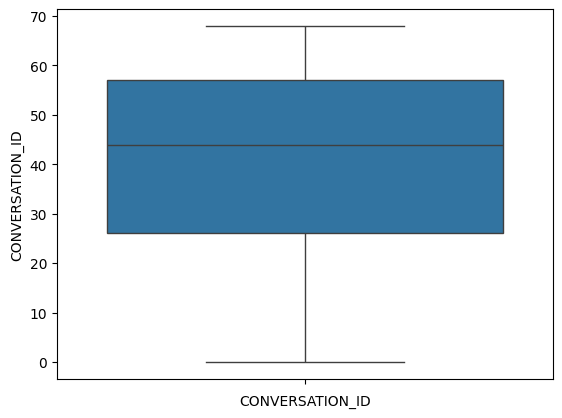

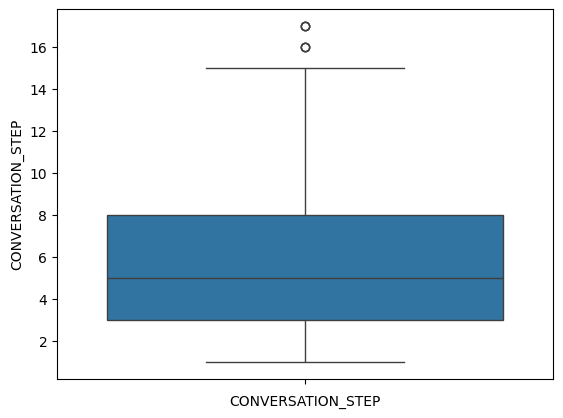

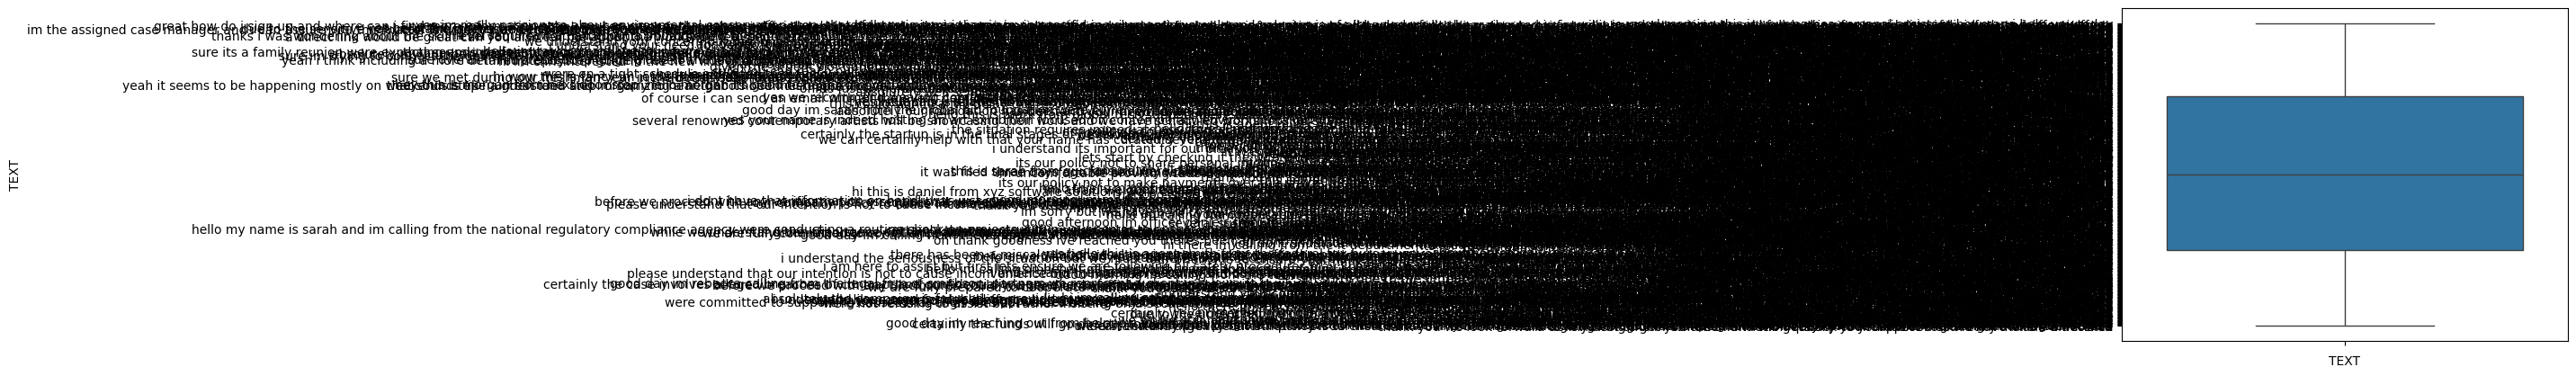

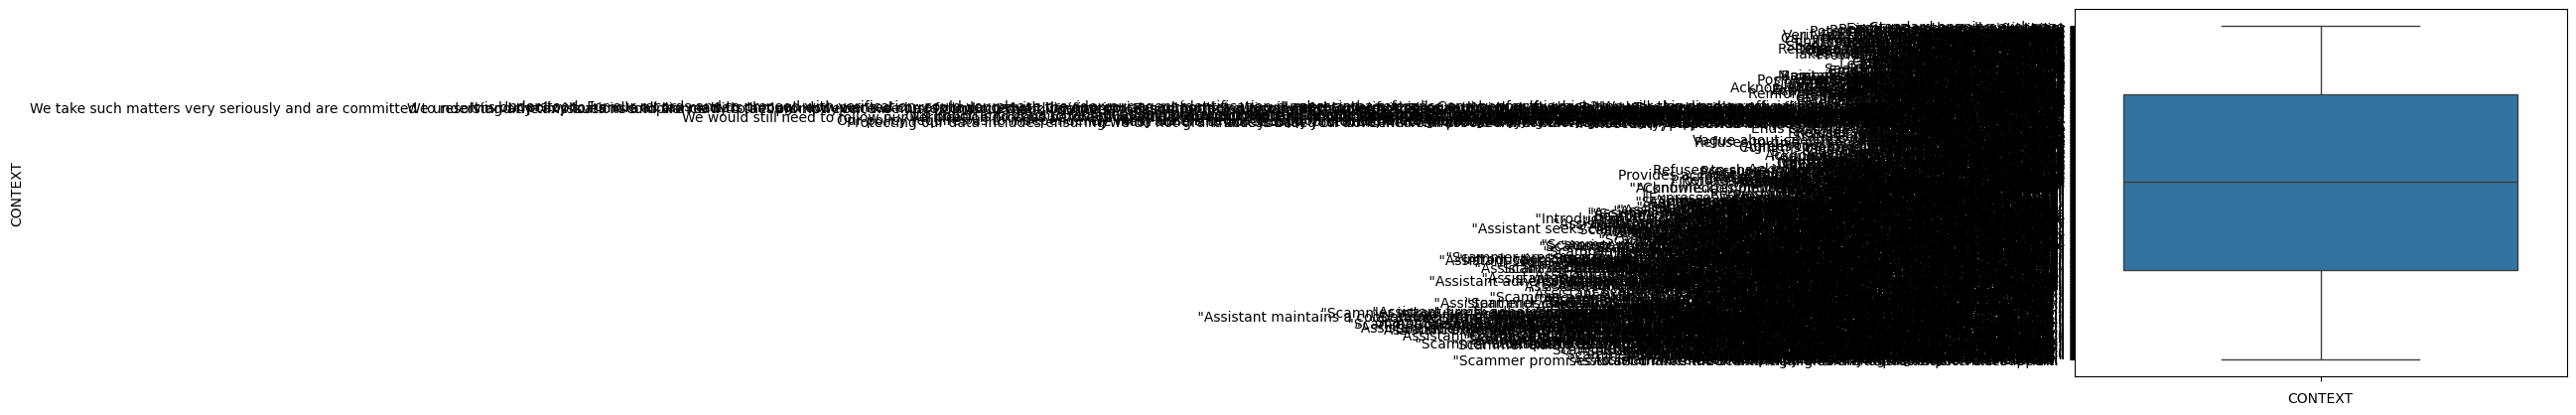

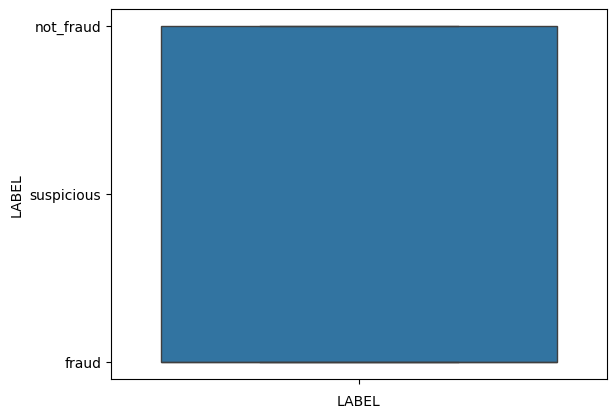

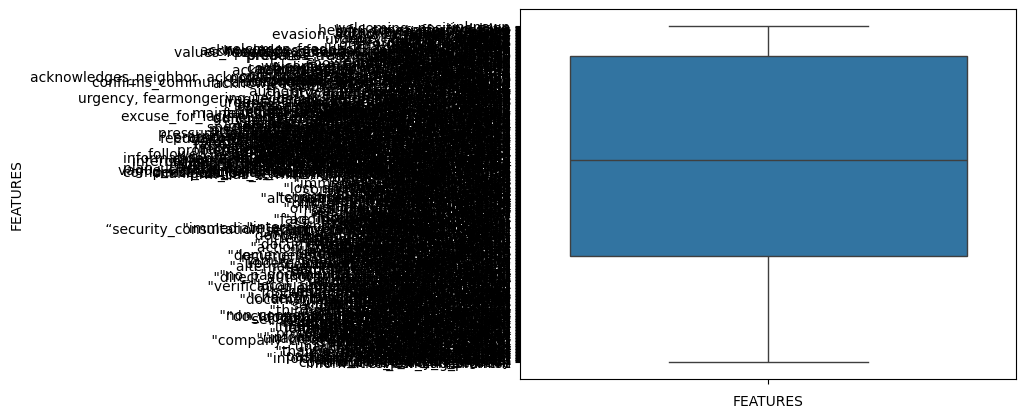

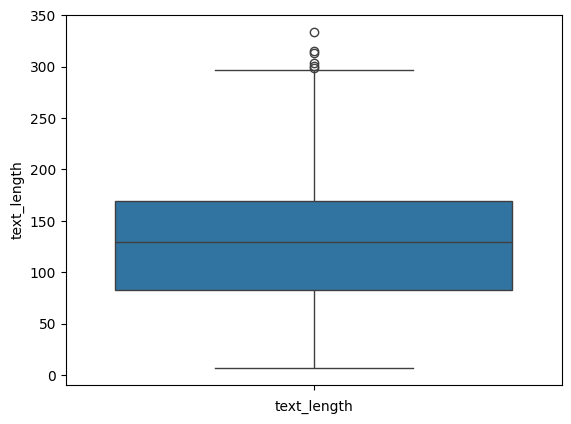

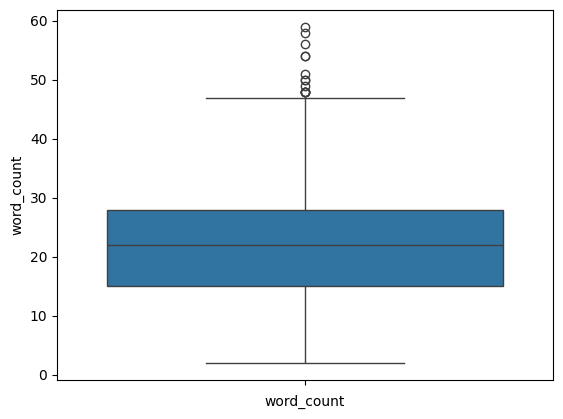

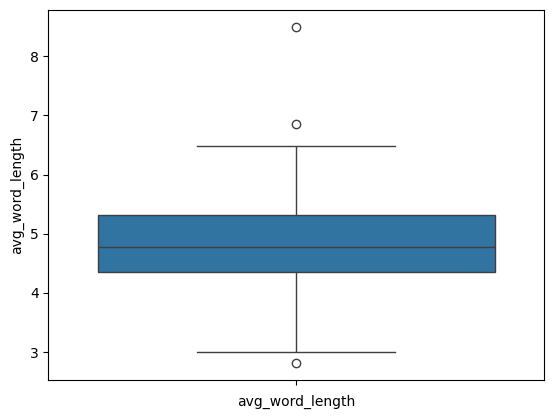

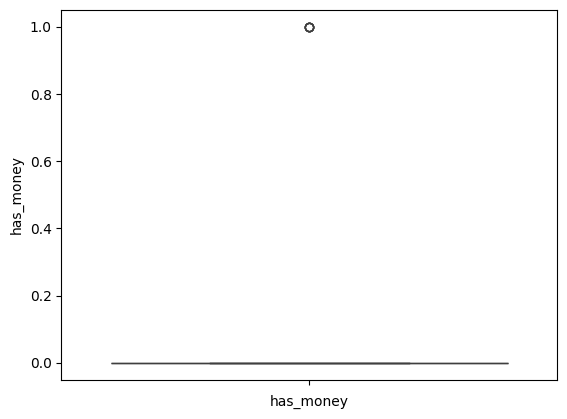

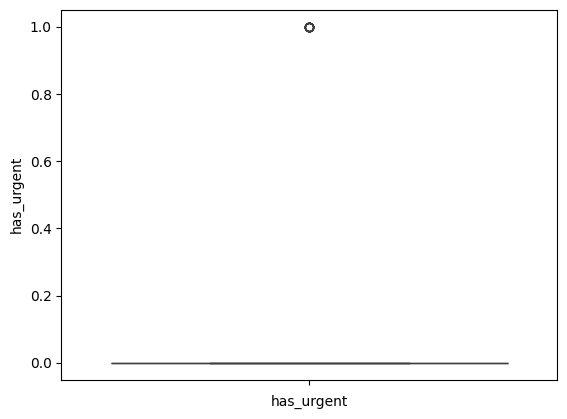

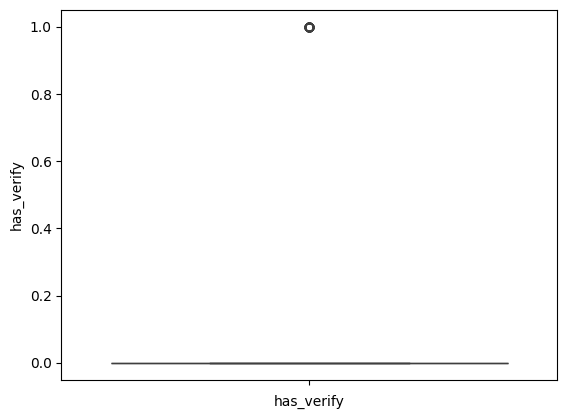

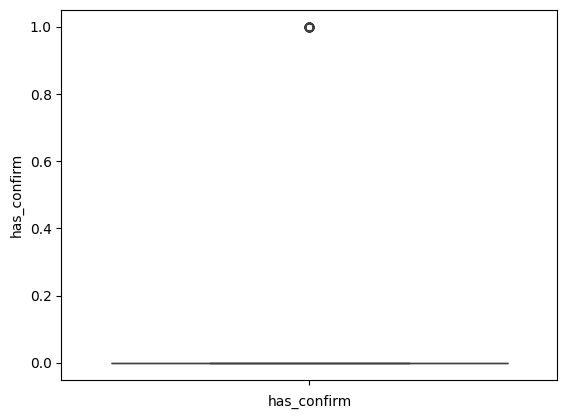

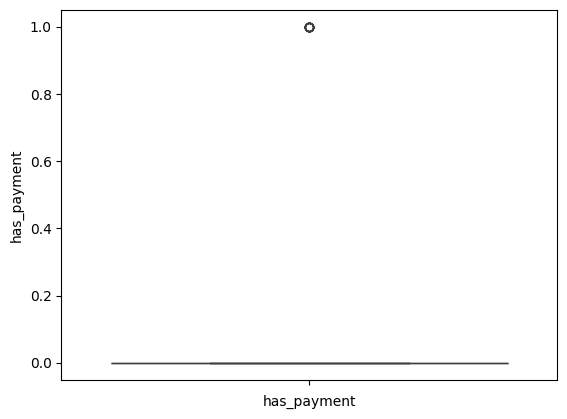

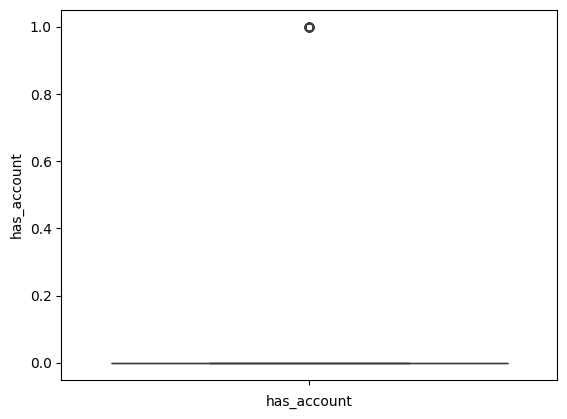

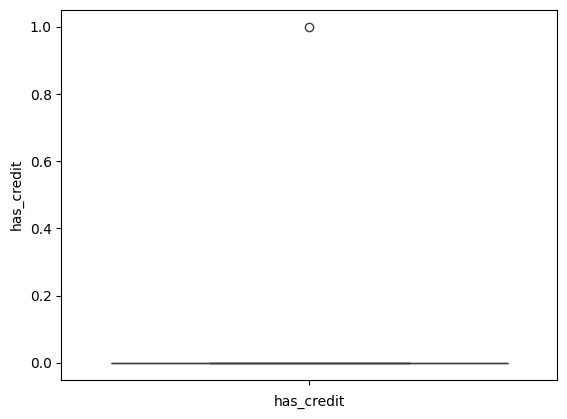

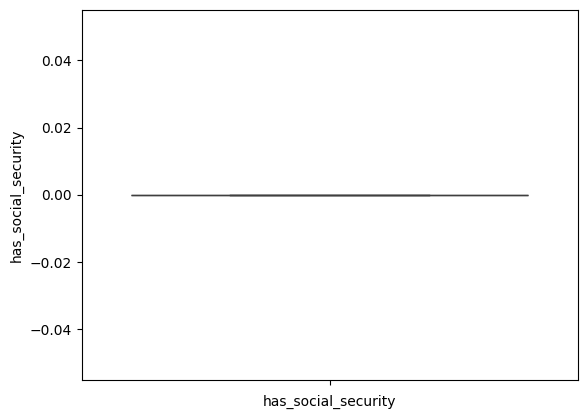

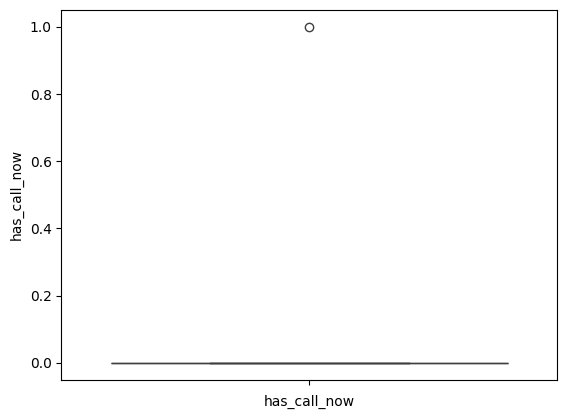

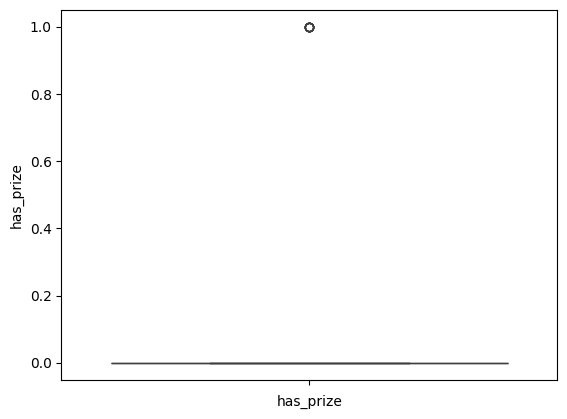

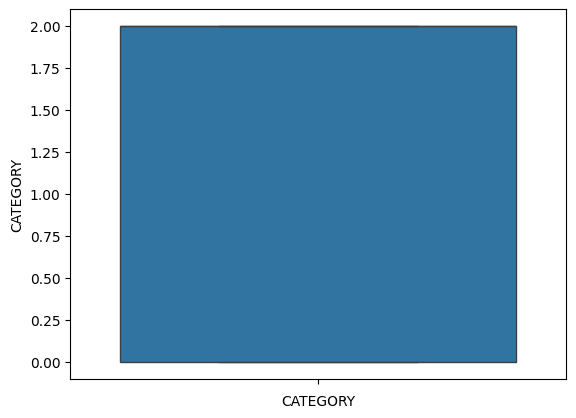

In [ ]:
for i in col:
  if df[i].dtypes!="objects":
    sns.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [ ]:
col_outliers=['CONVERSATION_STEP']
df["CONVERSATION_STEP"].value_counts()

,count
CONVERSATION_STEP,
2,65
3,65
1,64
4,64
5,64
6,64
7,53
8,44
9,37


In [ ]:
for i in col_outliers:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR=Q3-Q1
  lower_limit=Q1-1.5*IQR
  upper_limit=Q3+1.5*IQR
  df=df[(df[i]>=lower_limit) & (df[i]<=upper_limit)]

In [ ]:
col

['CONVERSATION_ID',
 'CONVERSATION_STEP',
 'TEXT',
 'CONTEXT',
 'LABEL',
 'FEATURES',
 'text_length',
 'word_count',
 'avg_word_length',
 'has_money',
 'has_urgent',
 'has_verify',
 'has_confirm',
 'has_payment',
 'has_account',
 'has_credit',
 'has_social_security',
 'has_call_now',
 'has_prize',
 'CATEGORY']

In [ ]:
col.remove("LABEL")

In [ ]:
X=df[col]
X

,CONVERSATION_ID,CONVERSATION_STEP,TEXT,CONTEXT,FEATURES,text_length,word_count,avg_word_length,has_money,has_urgent,has_verify,has_confirm,has_payment,has_account,has_credit,has_social_security,has_call_now,has_prize,CATEGORY
0,6,1,good morning this is your names personal assis...,Standard opening exchange,unknown,75,14,4.428571,0,0,0,0,0,0,0,0,0,0,0
1,6,2,hello my name is jamie im interested in volunt...,Encourages the caller's interest,"welcoming, positive_tone",202,32,5.312500,0,0,0,0,0,0,0,0,0,0,0
2,6,3,yes im really passionate about environmental c...,Reinforces anyone can volunteer,inclusive,270,39,5.923077,0,0,0,0,0,0,0,0,0,0,0
3,6,4,great how do i sign up and where can i find mo...,Demonstrates flexibility,"helpful_tone, offers_options",313,58,4.396552,0,0,0,0,0,0,0,0,0,0,0
4,6,5,could you send me the link please and my email...,Fulfills caller's request quickly,prompt_action,216,37,4.837838,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,68,5,would it be possible to receive some literatur...,"""Assistant requests official documentation fo...","""literature_request",155,25,5.240000,0,0,0,0,0,0,0,0,0,0,2
646,68,6,we can certainly provide information on our wo...,"""Scammer stresses the urgency of the situation.""","""immediate_action_urgency",165,29,4.724138,0,0,0,0,0,0,0,0,0,0,2
647,68,7,i understand the urgency but our policy is to ...,"""Assistant reiterates the policy on verifying...","""contribution_policy_reiteration",168,28,5.035714,0,0,0,0,0,0,0,0,0,0,2
648,68,8,ill do my best to get you the information quic...,"""Scammer promises to send information and hig...","""information_sending_promise",93,17,4.529412,0,0,0,0,0,0,0,0,0,0,2


In [ ]:
y=df['CATEGORY']
y

,CATEGORY
0,0
1,0
2,0
3,0
4,0
...,...
645,2
646,2
647,2
648,2


In [ ]:
col

['CONVERSATION_ID',
 'CONVERSATION_STEP',
 'TEXT',
 'CONTEXT',
 'FEATURES',
 'text_length',
 'word_count',
 'avg_word_length',
 'has_money',
 'has_urgent',
 'has_verify',
 'has_confirm',
 'has_payment',
 'has_account',
 'has_credit',
 'has_social_security',
 'has_call_now',
 'has_prize',
 'CATEGORY']

In [ ]:
df

,CONVERSATION_ID,CONVERSATION_STEP,TEXT,CONTEXT,LABEL,FEATURES,text_length,word_count,avg_word_length,has_money,has_urgent,has_verify,has_confirm,has_payment,has_account,has_credit,has_social_security,has_call_now,has_prize,CATEGORY
0,6,1,good morning this is your names personal assis...,Standard opening exchange,not_fraud,unknown,75,14,4.428571,0,0,0,0,0,0,0,0,0,0,0
1,6,2,hello my name is jamie im interested in volunt...,Encourages the caller's interest,not_fraud,"welcoming, positive_tone",202,32,5.312500,0,0,0,0,0,0,0,0,0,0,0
2,6,3,yes im really passionate about environmental c...,Reinforces anyone can volunteer,not_fraud,inclusive,270,39,5.923077,0,0,0,0,0,0,0,0,0,0,0
3,6,4,great how do i sign up and where can i find mo...,Demonstrates flexibility,not_fraud,"helpful_tone, offers_options",313,58,4.396552,0,0,0,0,0,0,0,0,0,0,0
4,6,5,could you send me the link please and my email...,Fulfills caller's request quickly,not_fraud,prompt_action,216,37,4.837838,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,68,5,would it be possible to receive some literatur...,"""Assistant requests official documentation fo...",fraud,"""literature_request",155,25,5.240000,0,0,0,0,0,0,0,0,0,0,2
646,68,6,we can certainly provide information on our wo...,"""Scammer stresses the urgency of the situation.""",fraud,"""immediate_action_urgency",165,29,4.724138,0,0,0,0,0,0,0,0,0,0,2
647,68,7,i understand the urgency but our policy is to ...,"""Assistant reiterates the policy on verifying...",fraud,"""contribution_policy_reiteration",168,28,5.035714,0,0,0,0,0,0,0,0,0,0,2
648,68,8,ill do my best to get you the information quic...,"""Scammer promises to send information and hig...",fraud,"""information_sending_promise",93,17,4.529412,0,0,0,0,0,0,0,0,0,0,2


In [ ]:
x=df.drop(["CONVERSATION_ID","CONVERSATION_STEP","CONTEXT","FEATURES","CATEGORY","LABEL"],axis=1)

In [ ]:
x

,TEXT,text_length,word_count,avg_word_length,has_money,has_urgent,has_verify,has_confirm,has_payment,has_account,has_credit,has_social_security,has_call_now,has_prize
0,good morning this is your names personal assis...,75,14,4.428571,0,0,0,0,0,0,0,0,0,0
1,hello my name is jamie im interested in volunt...,202,32,5.312500,0,0,0,0,0,0,0,0,0,0
2,yes im really passionate about environmental c...,270,39,5.923077,0,0,0,0,0,0,0,0,0,0
3,great how do i sign up and where can i find mo...,313,58,4.396552,0,0,0,0,0,0,0,0,0,0
4,could you send me the link please and my email...,216,37,4.837838,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,would it be possible to receive some literatur...,155,25,5.240000,0,0,0,0,0,0,0,0,0,0
646,we can certainly provide information on our wo...,165,29,4.724138,0,0,0,0,0,0,0,0,0,0
647,i understand the urgency but our policy is to ...,168,28,5.035714,0,0,0,0,0,0,0,0,0,0
648,ill do my best to get you the information quic...,93,17,4.529412,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='CATEGORY', ylabel='count'>

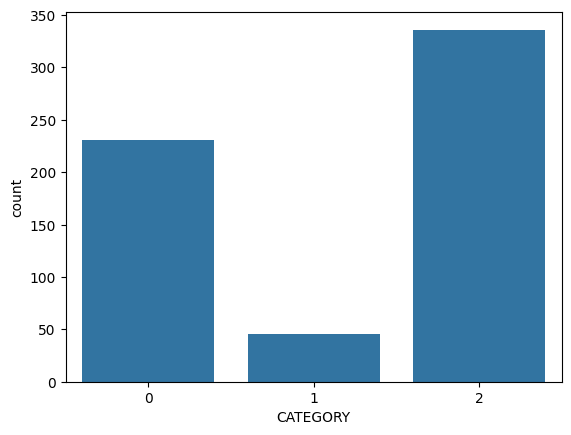

In [ ]:
import seaborn as sns
sns.countplot(x=y)

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
df.head()

,CONVERSATION_ID,CONVERSATION_STEP,TEXT,CONTEXT,LABEL,FEATURES,text_length,word_count,avg_word_length,has_money,has_urgent,has_verify,has_confirm,has_payment,has_account,has_credit,has_social_security,has_call_now,has_prize,CATEGORY
0,6,1,good morning this is your names personal assis...,Standard opening exchange,not_fraud,unknown,75,14,4.428571,0,0,0,0,0,0,0,0,0,0,0
1,6,2,hello my name is jamie im interested in volunt...,Encourages the caller's interest,not_fraud,"welcoming, positive_tone",202,32,5.312500,0,0,0,0,0,0,0,0,0,0,0
2,6,3,yes im really passionate about environmental c...,Reinforces anyone can volunteer,not_fraud,inclusive,270,39,5.923077,0,0,0,0,0,0,0,0,0,0,0
3,6,4,great how do i sign up and where can i find mo...,Demonstrates flexibility,not_fraud,"helpful_tone, offers_options",313,58,4.396552,0,0,0,0,0,0,0,0,0,0,0
4,6,5,could you send me the link please and my email...,Fulfills caller's request quickly,not_fraud,prompt_action,216,37,4.837838,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
x.head()

,TEXT,text_length,word_count,avg_word_length,has_money,has_urgent,has_verify,has_confirm,has_payment,has_account,has_credit,has_social_security,has_call_now,has_prize
0,good morning this is your names personal assis...,75,14,4.428571,0,0,0,0,0,0,0,0,0,0
1,hello my name is jamie im interested in volunt...,202,32,5.312500,0,0,0,0,0,0,0,0,0,0
2,yes im really passionate about environmental c...,270,39,5.923077,0,0,0,0,0,0,0,0,0,0
3,great how do i sign up and where can i find mo...,313,58,4.396552,0,0,0,0,0,0,0,0,0,0
4,could you send me the link please and my email...,216,37,4.837838,0,0,0,0,0,0,0,0,0,0


In [ ]:
ps = WordNetLemmatizer()

corpos = []
for i in range(len(x)):
    review = re.sub('[^a-zA-Z]', ' ', str(x['TEXT'].iloc[i]))
    review = review.lower()
    review = review.split()
    review = [ps.lemmatize(word) for word in review if word not in stopwords.words('english')]
    review = ' '.join(review)
    corpos.append(review)

x['clean_text'] = corpos

In [ ]:
cv = TfidfVectorizer(max_features=2000)
X_tfidf = cv.fit_transform(x['clean_text']).toarray()

# Select numeric/statistical columns
stat_cols = ['text_length', 'word_count', 'avg_word_length'] + [col for col in df.columns if col.startswith('has_')]
X_stats = df[stat_cols].values

# Combine TF-IDF + statistical features
X = np.hstack([X_tfidf, X_stats])


In [ ]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
y

,CATEGORY
0,0
1,0
2,0
3,0
4,0
...,...
645,2
646,2
647,2
648,2


In [ ]:
x

,TEXT,text_length,word_count,avg_word_length,has_money,has_urgent,has_verify,has_confirm,has_payment,has_account,has_credit,has_social_security,has_call_now,has_prize,clean_text
0,good morning this is your names personal assis...,75,14,4.428571,0,0,0,0,0,0,0,0,0,0,good morning name personal assistant help today
1,hello my name is jamie im interested in volunt...,202,32,5.312500,0,0,0,0,0,0,0,0,0,0,hello name jamie im interested volunteering st...
2,yes im really passionate about environmental c...,270,39,5.923077,0,0,0,0,0,0,0,0,0,0,yes im really passionate environmental conserv...
3,great how do i sign up and where can i find mo...,313,58,4.396552,0,0,0,0,0,0,0,0,0,0,great sign find information step sign official...
4,could you send me the link please and my email...,216,37,4.837838,0,0,0,0,0,0,0,0,0,0,could send link please email jamiegreenexample...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,would it be possible to receive some literatur...,155,25,5.240000,0,0,0,0,0,0,0,0,0,0,would possible receive literature organization...
646,we can certainly provide information on our wo...,165,29,4.724138,0,0,0,0,0,0,0,0,0,0,certainly provide information work find immedi...
647,i understand the urgency but our policy is to ...,168,28,5.035714,0,0,0,0,0,0,0,0,0,0,understand urgency policy ensure contribution ...
648,ill do my best to get you the information quic...,93,17,4.529412,0,0,0,0,0,0,0,0,0,0,ill best get information quickly support could...


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
y_train.head(10)

,CATEGORY
402,2
375,2
118,0
79,1
23,0
163,0
342,2
135,0
347,2
445,2


In [ ]:
y_test

,CATEGORY
403,1
101,0
131,0
426,0
646,2
...,...
387,2
83,1
90,1
632,2


In [ ]:
nb = MultinomialNB()
nb.fit(x_train, y_train)
y_pred_nb = nb.predict(x_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("-----------------------------------------")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("-----------------------------------------")
print("Classification Report:\n", classification_report(y_test, y_pred_nb))
print("-----------------------------------------")

Naive Bayes Accuracy: 0.6910569105691057
-----------------------------------------
Confusion Matrix:
 [[21  0 26]
 [ 1  0 11]
 [ 0  0 64]]
-----------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.45      0.61        47
           1       0.00      0.00      0.00        12
           2       0.63      1.00      0.78        64

    accuracy                           0.69       123
   macro avg       0.53      0.48      0.46       123
weighted avg       0.69      0.69      0.64       123

-----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("-----------------------------------------")
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("-----------------------------------------")

Decision Tree Accuracy: 0.7804878048780488
-----------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.83      0.77        47
           1       0.67      0.33      0.44        12
           2       0.84      0.83      0.83        64

    accuracy                           0.78       123
   macro avg       0.74      0.66      0.68       123
weighted avg       0.78      0.78      0.77       123

-----------------------------------------


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8211382113821138
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.83        47
           1       0.00      0.00      0.00        12
           2       0.79      1.00      0.88        64

    accuracy                           0.82       123
   macro avg       0.56      0.60      0.57       123
weighted avg       0.75      0.82      0.78       123



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
nn = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
nn.fit(x_train, y_train)
y_pred_nn = nn.predict(x_test)

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Classification Report:\n", classification_report(y_test, y_pred_nn))


Neural Network Accuracy: 0.8292682926829268
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.87      0.90        47
           1       0.00      0.00      0.00        12
           2       0.78      0.95      0.86        64

    accuracy                           0.83       123
   macro avg       0.57      0.61      0.59       123
weighted avg       0.76      0.83      0.79       123



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, auc, classification_report)
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
y

,CATEGORY
0,0
1,0
2,0
3,0
4,0
...,...
645,2
646,2
647,2
648,2


In [ ]:
x

,TEXT,text_length,word_count,avg_word_length,has_money,has_urgent,has_verify,has_confirm,has_payment,has_account,has_credit,has_social_security,has_call_now,has_prize,clean_text
0,good morning this is your names personal assis...,75,14,4.428571,0,0,0,0,0,0,0,0,0,0,good morning name personal assistant help today
1,hello my name is jamie im interested in volunt...,202,32,5.312500,0,0,0,0,0,0,0,0,0,0,hello name jamie im interested volunteering st...
2,yes im really passionate about environmental c...,270,39,5.923077,0,0,0,0,0,0,0,0,0,0,yes im really passionate environmental conserv...
3,great how do i sign up and where can i find mo...,313,58,4.396552,0,0,0,0,0,0,0,0,0,0,great sign find information step sign official...
4,could you send me the link please and my email...,216,37,4.837838,0,0,0,0,0,0,0,0,0,0,could send link please email jamiegreenexample...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,would it be possible to receive some literatur...,155,25,5.240000,0,0,0,0,0,0,0,0,0,0,would possible receive literature organization...
646,we can certainly provide information on our wo...,165,29,4.724138,0,0,0,0,0,0,0,0,0,0,certainly provide information work find immedi...
647,i understand the urgency but our policy is to ...,168,28,5.035714,0,0,0,0,0,0,0,0,0,0,understand urgency policy ensure contribution ...
648,ill do my best to get you the information quic...,93,17,4.529412,0,0,0,0,0,0,0,0,0,0,ill best get information quickly support could...


In [ ]:
y

,CATEGORY
0,0
1,0
2,0
3,0
4,0
...,...
645,2
646,2
647,2
648,2


In [ ]:
y.unique()

array([0, 1, 2])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
new_text = ["This call is from the government. They like to know your card details"]
new_vector = cv.transform(new_text)
prediction = nn.predict(new_vector)
proba = nn.predict_proba(new_vector)
classes = nn.classes_

# show result
for cls, p in zip(classes, proba[0]):
    print(f"{cls}: {p*100:.2f}%")

ValueError: X has 1441 features, but MLPClassifier is expecting 1454 features as input.

In [ ]:
prediction

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
new_text = ["Hey this side Rahul. Could you contact me soon"]
new_vector = cv.transform(new_text)
prediction2 = nn.predict(new_vector)
proba = nn.predict_proba(new_vector)
classes = nn.classes_

# show result
for cls, p in zip(classes, proba[0]):
    print(f"{cls}: {p*100:.2f}%")

In [ ]:
prediction2

In [ ]:
#Random Forest
print(f"Random Forest -> Train Accuracy: {np.round(accuracy_score(y_train, rf.predict(x_train))*100, 2)}")
print(f"Random Forest -> Test Accuracy: {np.round(accuracy_score(y_test, y_pred_rf)*100, 2)}")

In [ ]:
# HyperParameter Tuning using RandomSearchCV
from sklearn.model_selection import RandomizedSearchCV

parameter_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [10,12,15,18],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,5]
}

# Create a Ransom Forest Classifier
rf2 = RandomForestClassifier(random_state = 42)

# Create a Random Search
random_search = RandomizedSearchCV(estimator = rf2,
                                   param_distributions = parameter_grid,
                                   n_iter = 10,
                                   cv = 5,
                                   random_state = 42)

# Fit the tuned model
rf_tuned = random_search.fit(x_train, y_train)

# Fit the tuned Model

rf_tuned= random_search.fit(x_train, y_train)

In [ ]:
# Best Params
rf_tuned.best_params_

In [ ]:
# Prediction using tuned model
rf_tuned_pred= rf_tuned.predict(x_test)

In [ ]:
#Random Forest - Tuned
print(f"Random Forest Tuned -> Train Accuracy: {np.round(accuracy_score(y_train, rf_tuned.predict(x_train))*100, 2)}")
print(f"Random Forest Tuned -> Test Accuracy: {np.round(accuracy_score(y_test, rf_tuned_pred)*100, 2)}")

In [ ]:
rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(x_train, y_train)
y_pred_rf2 = rf2.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf2))
print("Classification Report:\n", classification_report(y_test, y_pred_rf2))


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
new_text = ["Hey this side Rahul. Could you contact me soon"]
new_vector = cv.transform(new_text)
prediction2 = nb.predict(new_vector)
proba = nb.predict_proba(new_vector)
classes = nb.classes_

# show result
for cls, p in zip(classes, proba[0]):
    print(f"{cls}: {p*100:.2f}%")

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
# Checking Confusion Metrix
cnf_matrix = confusion_matrix(y_test, y_pred_nn)

# confusion metrics
plt.figure(figsize=(6,6))
ax = sns.heatmap(pd.DataFrame(cnf_matrix), annot = True, cmap = 'viridis_r', fmt = 'd')
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred_nn))